# Baseline Topic Model Analysis

This notebook analyzes and compares the results of baseline topic models (BERTopic, BERTopic_FinBert, LDA, Top2Vec) using exported metrics and topic information from the `Outputs/Comparisons_03` directory.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and any other libraries needed for data analysis and visualization.

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
display_available = False
try:
    from IPython.display import display
    display_available = True
except ImportError:
    pass

## 2. Load Metrics Summary Tables
Read the `metrics_summary.csv` files from each model's tables directory into pandas DataFrames for comparison.

In [4]:
# Define paths to metrics_summary.csv for each model
base_dir = 'Code/Outputs/Comparisons_03'
model_dirs = {
    'BERTopic': 'BERTopic/20260416_212154/tables/metrics_summary.csv',
    'BERTopic_FinBert': 'BERTopic_FinBert/20260416_212943/tables/metrics_summary.csv',
    'LDA': 'LDA/20260416_213414/tables/metrics_summary.csv',
    'Top2Vec': 'Top2Vec/20260416_213040/tables/metrics_summary.csv',
}

metrics = {}
for model, rel_path in model_dirs.items():
    path = os.path.join(base_dir, rel_path)
    df = pd.read_csv(path)
    metrics[model] = df
    print(f"Loaded metrics for {model} from {path}")

Loaded metrics for BERTopic from Code/Outputs/Comparisons_03\BERTopic/20260416_212154/tables/metrics_summary.csv
Loaded metrics for BERTopic_FinBert from Code/Outputs/Comparisons_03\BERTopic_FinBert/20260416_212943/tables/metrics_summary.csv
Loaded metrics for LDA from Code/Outputs/Comparisons_03\LDA/20260416_213414/tables/metrics_summary.csv
Loaded metrics for Top2Vec from Code/Outputs/Comparisons_03\Top2Vec/20260416_213040/tables/metrics_summary.csv


## 3. Compare Topic Modeling Metrics Across Models
Aggregate and compare key metrics (e.g., coherence, diversity) from all models in a single DataFrame for side-by-side analysis.

In [8]:
# Load and pivot metrics_summary.csv for each model
comparison = {}
for model, rel_path in model_dirs.items():
    path = os.path.join(base_dir, rel_path)
    df = pd.read_csv(path)
    # Pivot so metric names become columns
    metrics_dict = df.set_index('metric')['value'].to_dict()
    cv = metrics_dict.get('coherence_c_v', None)
    diversity = metrics_dict.get('topic_diversity', None)
    comparison[model] = {'C_v': cv, 'Diversity': diversity}
    print(f"{model}: C_v={cv}, Diversity={diversity}")

comparison_df = pd.DataFrame(comparison).T
comparison_df.index.name = 'Model'
if display_available:
    display(comparison_df)
else:
    print(comparison_df)

# LaTeX-ready table
print("\nLaTeX Table:\n")
print(comparison_df.to_latex(float_format="{:.3f}".format))

BERTopic: C_v=0.7853157515311892, Diversity=0.8214285714285714
BERTopic_FinBert: C_v=0.645698020273403, Diversity=0.9333333333333332
LDA: C_v=0.5556940356818761, Diversity=0.6083333333333333
Top2Vec: C_v=0.3678796440405271, Diversity=0.132


,C_v,Diversity
Model,,
BERTopic,0.785316,0.821429
BERTopic_FinBert,0.645698,0.933333
LDA,0.555694,0.608333
Top2Vec,0.367880,0.132000



LaTeX Table:

\begin{tabular}{lrr}
\toprule
 & C_v & Diversity \\
Model &  &  \\
\midrule
BERTopic & 0.785 & 0.821 \\
BERTopic_FinBert & 0.646 & 0.933 \\
LDA & 0.556 & 0.608 \\
Top2Vec & 0.368 & 0.132 \\
\bottomrule
\end{tabular}



## 4. Visualize Key Metrics
Create bar plots to compare C_v and Diversity across models.

C:\Users\gianf\AppData\Local\Temp\ipykernel_25876\2516005544.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y='C_v', data=comparison_df.reset_index(), ax=ax[0], palette='Blues_d')
C:\Users\gianf\AppData\Local\Temp\ipykernel_25876\2516005544.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y='Diversity', data=comparison_df.reset_index(), ax=ax[1], palette='Greens_d')


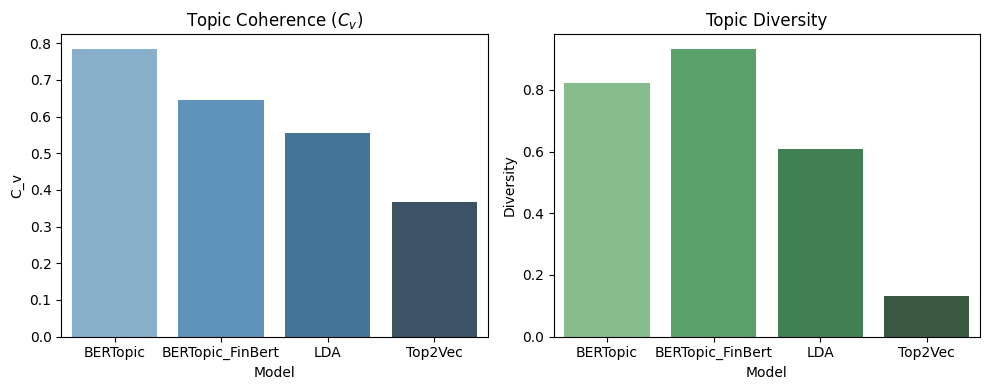

In [10]:
# Bar plot for C_v and Diversity
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x=comparison_df.index, y='C_v', data=comparison_df.reset_index(), ax=ax[0], palette='Blues_d')
ax[0].set_title('Topic Coherence ($C_v$)')
ax[0].set_ylabel('C_v')
ax[0].set_xlabel('Model')
sns.barplot(x=comparison_df.index, y='Diversity', data=comparison_df.reset_index(), ax=ax[1], palette='Greens_d')
ax[1].set_title('Topic Diversity')
ax[1].set_ylabel('Diversity')
ax[1].set_xlabel('Model')
plt.tight_layout()
plt.show()

## 5. Load and Explore Topic Information
Load `topic_info.csv` or `topic_prevalence.csv` (where available) to examine the number of topics, topic sizes, and prevalence per model.

In [11]:
# Load topic info/prevalence for each model
info_files = {
    'BERTopic': 'BERTopic/20260416_212154/tables/topic_info.csv',
    'BERTopic_FinBert': 'BERTopic_FinBert/20260416_212943/tables/topic_info.csv',
    'LDA': 'LDA/20260416_213414/tables/topic_prevalence.csv',
    'Top2Vec': 'Top2Vec/20260416_213040/tables/topic_prevalence.csv',
}
topic_infos = {}
for model, rel_path in info_files.items():
    path = os.path.join(base_dir, rel_path)
    if os.path.exists(path):
        df = pd.read_csv(path)
        topic_infos[model] = df
        print(f"Loaded topic info for {model} ({len(df)} topics)")
    else:
        print(f"Topic info not found for {model}")

# Show number of topics per model
for model, df in topic_infos.items():
    print(f"{model}: {len(df)} topics")
    if display_available:
        display(df.head())
    else:
        print(df.head())

Loaded topic info for BERTopic (15 topics)
Loaded topic info for BERTopic_FinBert (3 topics)
Loaded topic info for LDA (12 topics)
Loaded topic info for Top2Vec (10 topics)
BERTopic: 15 topics


,Topic,Count,Name,Representation,Representative_Docs
0,-1,110,-1_billion_bank_reserve_federal,"['billion', 'bank', 'reserve', 'federal', 'cit...",['American International Group (AIG) announces...
1,0,81,0_covid_19_cdc_states,"['covid', '19', 'cdc', 'states', 'united', 're...","['The CDC reports that over 500,000 people hav..."
2,1,60,1_facility_backed_securities_talf,"['facility', 'backed', 'securities', 'talf', '...",['Treasury Secretary Mnuchin announces that he...
3,2,54,2_financial_federal_capital_reserve,"['financial', 'federal', 'capital', 'reserve',...","[""The Federal Reserve Board provides additiona..."
4,3,30,3_rate_percent_votes_points,"['rate', 'percent', 'votes', 'points', 'target...",['The FOMC votes to reduce its target for the ...


BERTopic_FinBert: 3 topics


,Topic,Count,Name,Representation,Representative_Docs
0,0,476,0_federal_reserve_billion_treasury,"['federal', 'reserve', 'billion', 'treasury', ...","[""The Federal Reserve announces additional act..."
1,1,32,1_purchases_total_stock_preferred,"['purchases', 'total', 'stock', 'preferred', '...",['The U.S. Treasury purchases a total of $45.5...
2,2,12,2_died_people_cdc_united,"['died', 'people', 'cdc', 'united', 'reports',...","['The CDC reports that over 250,000 people hav..."


LDA: 12 topics


,topic,documents
0,3,70
1,5,65
2,7,56
3,0,50
4,10,44


Top2Vec: 10 topics


,topic,documents
0,0,106
1,1,95
2,2,79
3,3,56
4,4,39


## 6. Analyze Topic Terms
Load `topic_terms_long.csv` for each model and analyze the top terms per topic, optionally visualizing word distributions.

In [14]:
# Show top 10 terms for topic 0 in BERTopic as example
if 'BERTopic' in topic_terms:
    df = topic_terms['BERTopic']
    # The columns are: topic_id, term_rank, term, weight
    print("Top 10 terms for topic 0 (BERTopic):")
    print(df[df['topic_id'] == 0].nsmallest(10, 'term_rank')[['term', 'weight']])

Top 10 terms for topic 0 (BERTopic):
        term    weight
0      covid  0.093820
1         19  0.085681
2        cdc  0.077448
3     states  0.065664
4     united  0.062946
5    reports  0.050376
6     people  0.044611
7    vaccine  0.041841
8  president  0.037589
9     health  0.036181


## 7. Compare Topic Assignments at Row Level
Load `row_topic_assignments.csv` for each model and compare topic assignments for the same documents across models.

In [15]:
# Load row_topic_assignments.csv for each model
row_files = {
    'BERTopic': 'BERTopic/20260416_212154/row_level/row_topic_assignments.csv',
    'BERTopic_FinBert': 'BERTopic_FinBert/20260416_212943/row_level/row_topic_assignments.csv',
    'LDA': 'LDA/20260416_213414/row_level/row_topic_assignments.csv',
    'Top2Vec': 'Top2Vec/20260416_213040/row_level/row_topic_assignments.csv',
}
row_assignments = {}
for model, rel_path in row_files.items():
    path = os.path.join(base_dir, rel_path)
    if os.path.exists(path):
        df = pd.read_csv(path)
        row_assignments[model] = df
        print(f"Loaded row topic assignments for {model}")
    else:
        print(f"Row topic assignments not found for {model}")

# Example: Compare topic assignments for the first 5 documents across all models
rows = []
for model, df in row_assignments.items():
    # Try to handle both 'document_id' and 'Document' column names, and 'topic'/'Topic'
    doc_col = 'document_id' if 'document_id' in df.columns else 'Document'
    topic_col = 'topic' if 'topic' in df.columns else 'Topic'
    if doc_col in df.columns and topic_col in df.columns:
        rows.append(df[[doc_col, topic_col]].rename(columns={topic_col: f'topic_{model}'}).set_index(doc_col))
if rows:
    merged = pd.concat(rows, axis=1, join='inner')
    print("Topic assignments for first 5 documents:")
    print(merged.head())

Loaded row topic assignments for BERTopic
Loaded row topic assignments for BERTopic_FinBert
Loaded row topic assignments for LDA
Loaded row topic assignments for Top2Vec
